# Part 1 : Data preprocessing
- load the 2 datasets
- normalize the pixel values to [0, 1]
- reduce dataset (Optional)
- training and testing

In [ ]:
import tensorflow as tf


(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = tf.keras.datasets.cifar10.load_data()

print(len(X_train_mnist))
print(len(X_train_cifar))

X_train_mnist = X_train_mnist / 255.0
X_test_mnist = X_test_mnist / 255.0

X_train_cifar = X_train_cifar / 255.0
X_test_cifar = X_test_cifar / 255.0

X_train_mnist = X_train_mnist.reshape(-1, 28, 28, 1)
X_test_mnist = X_test_mnist.reshape(-1, 28, 28, 1)

print(X_train_mnist.shape)
print(X_test_mnist.shape)

print(X_train_cifar.shape)
print(X_test_cifar.shape)

print(y_train_mnist.shape)
print(y_train_cifar.shape)


60000
50000
(60000, 28, 28, 1)
(10000, 28, 28, 1)
(50000, 32, 32, 3)
(10000, 32, 32, 3)
(60000,)
(50000, 1)


# Part 2 : Model implemenatation
- A.  Custom CNN Model
    - min 2 conv layers
    - pooling
    - softmax at the end

    - we may vary :
        - nr of filters
        - kernel sizes
        - dropout
        - activation functions

- B. AlexNet Model


In [62]:
from tensorflow.keras import layers, models

def original_model_choosing(input_size) :

    original_model = models.Sequential([
        
        layers.Conv2D(32, kernel_size=(3, 3), input_shape= input_size, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        layers.Conv2D(64, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        # layers.MaxPooling2D(pool_size=(2, 2)),
        
        layers.Conv2D(128, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        layers.Flatten(),
        
        layers.Dense(256),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        
        layers.Dense(10, activation='softmax')
    ])
    
    return original_model

In [63]:
original_model_mnist = original_model_choosing((28, 28, 1))
original_model_cifar = original_model_choosing((32, 32, 3))

d:\Info\AnacondaFolder\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
import time

def train_and_evaluate(model, X_train, y_train, X_test, y_test, 
                       epochs=20, batch_size=64, val_split=0.1):
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    start = time.time()
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_split=val_split, verbose=1)
    train_time = time.time() - start
    
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    model_size = model.count_params()
    
    print(f"  Test Accuracy: {test_acc:.4f}")
    print(f"  Training Time: {train_time:.2f}s")
    print(f"  Model Size:    {model_size:,} parameters")
    
    return {
        'history': history.history,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'train_time': train_time,
        'model_size': model_size,
        'model': model
    }

In [ ]:
analytics = train_and_evaluate(original_model_mnist, X_train_mnist, y_train_mnist,
                   X_test_mnist, y_test_mnist, epochs=5, batch_size=64, val_split=0.1)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.9908 - loss: 0.0290 - val_accuracy: 0.9897 - val_loss: 0.0386
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9938 - loss: 0.0196 - val_accuracy: 0.9918 - val_loss: 0.0328
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9956 - loss: 0.0136 - val_accuracy: 0.9928 - val_loss: 0.0334
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9965 - loss: 0.0110 - val_accuracy: 0.9918 - val_loss: 0.0353
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9975 - loss: 0.0075 - val_accuracy: 0.9912 - val_loss: 0.0377
  Test Accuracy: 0.9904
  Training Time: 64.39s
  Model Size:    225,034 parameters
{'accuracy': [0.9907962679862976, 0.9938333630561829, 0.9956111311912537, 0.9964629411697388, 0.9975185394287109], 'loss': [0.028960449621081352, 0.01962476409971714, 0.013645331375300884, 0.010990114882588387, 0.0074748508632183075], 'val_accuracy': [0.9896666407585144,

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_results(result, X_test, y_test):
    
    h = result['history']
    model = result['model']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(h['loss'], label='Train Loss')
    axes[0].plot(h['val_loss'], label='Val Loss')
    axes[0].set_title(f'Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    
    axes[1].plot(h['accuracy'], label='Train Acc')
    axes[1].plot(h['val_accuracy'], label='Val Acc')
    axes[1].set_title(f'Accuracy: (Test: {result["test_acc"]:.4f})')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    y_true = y_test.flatten()
    
    cm = confusion_matrix(y_true, y_pred_classes)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

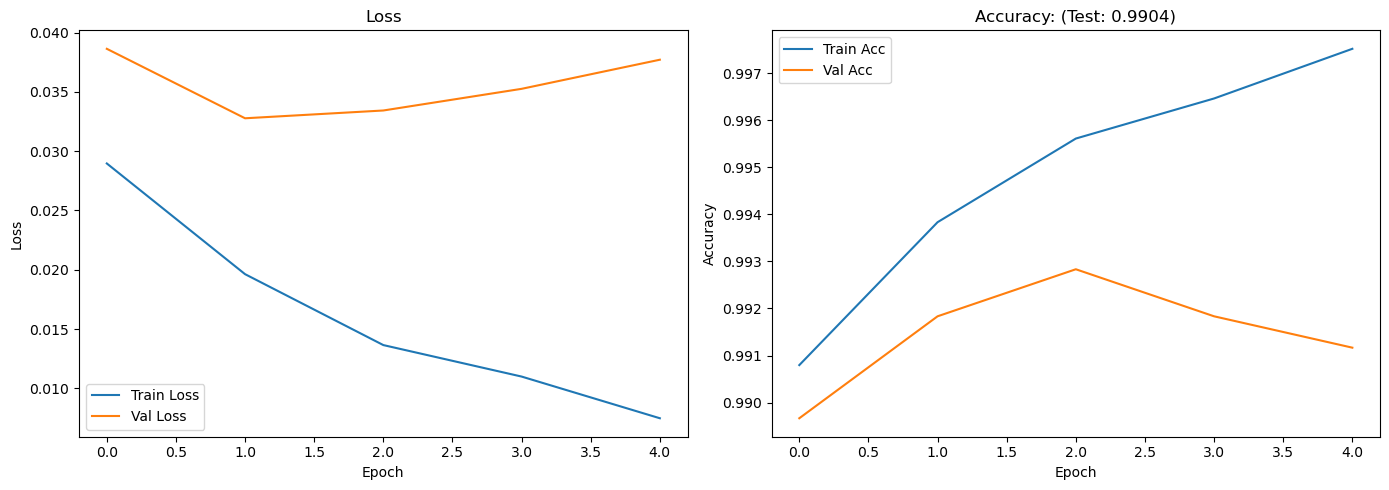

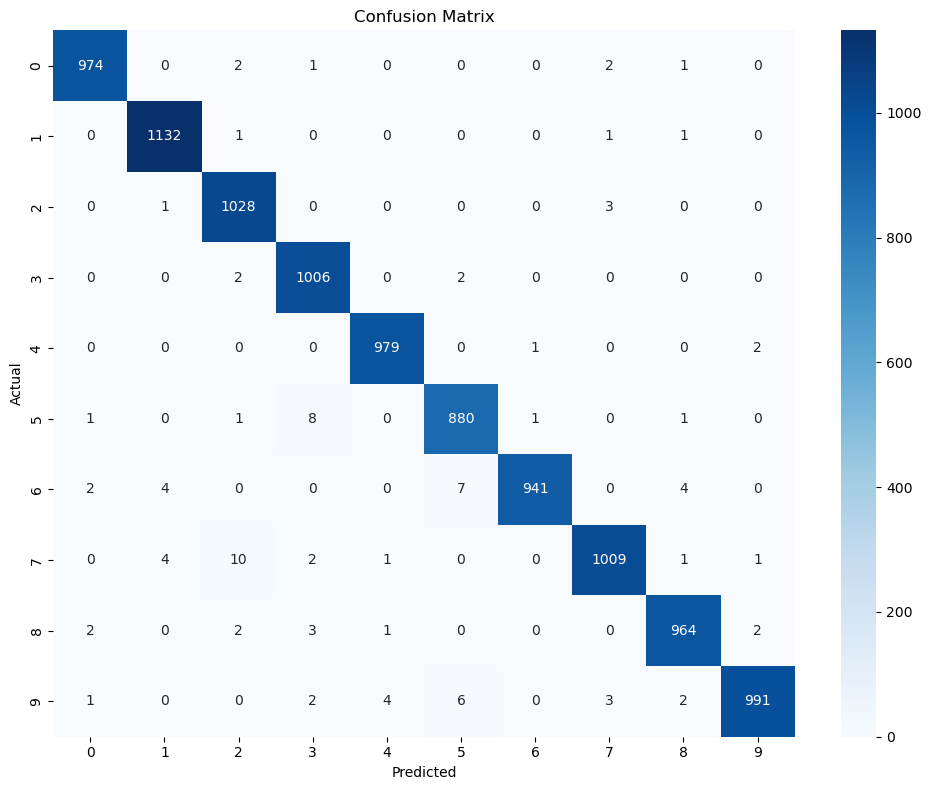

In [33]:
plot_results(analytics, X_test_mnist, y_test_mnist)

* AlexNet model for the MNIST dataset

In [35]:
def alex_net_choosing(input_size) :
    alex_net_model = models.Sequential([
        layers.Conv2D(96, kernel_size = (3, 3), strides = (1, 1), input_shape = input_size, padding='same'),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        layers.BatchNormalization(),
        
        layers.Conv2D(256, kernel_size = (3, 3), strides = (1, 1), padding='same'),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        layers.BatchNormalization(),
        
        layers.Conv2D(384, kernel_size=(3, 3), strides = (1, 1), padding='same'),
        layers.Activation('relu'),
        
        layers.Conv2D(384, kernel_size=(3, 3), strides = (1, 1), padding='same'),
        layers.Activation('relu'),
        
        layers.Conv2D(256, kernel_size=(3, 3), strides = (1, 1), padding='same'),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2), strides = (2, 2)),
        
        layers.Flatten(),
        
        layers.Dense(1024),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        
        layers.Dense(512),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        
        layers.Dense(10),
        layers.Activation('softmax')
    ])
    
    return alex_net_model
    

In [36]:
alex_net_model_mnist = alex_net_choosing((28, 28, 1))
alex_net_model_cifar = alex_net_choosing((32, 32, 3))

d:\Info\AnacondaFolder\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 328s 383ms/step - accuracy: 0.9340 - loss: 0.2182 - val_accuracy: 0.9848 - val_loss: 0.0601
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 321s 381ms/step - accuracy: 0.9796 - loss: 0.0788 - val_accuracy: 0.9865 - val_loss: 0.0721
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 323s 383ms/step - accuracy: 0.9849 - loss: 0.0613 - val_accuracy: 0.9832 - val_loss: 0.0793
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 338s 400ms/step - accuracy: 0.9856 - loss: 0.0615 - val_accuracy: 0.9917 - val_loss: 0.0399
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 342s 405ms/step - accuracy: 0.9889 - loss: 0.0474 - val_accuracy: 0.9860 - val_loss: 0.0663
  Test Accuracy: 0.9873
  Training Time: 1652.53s
  Model Size:    6,211,658 parameters


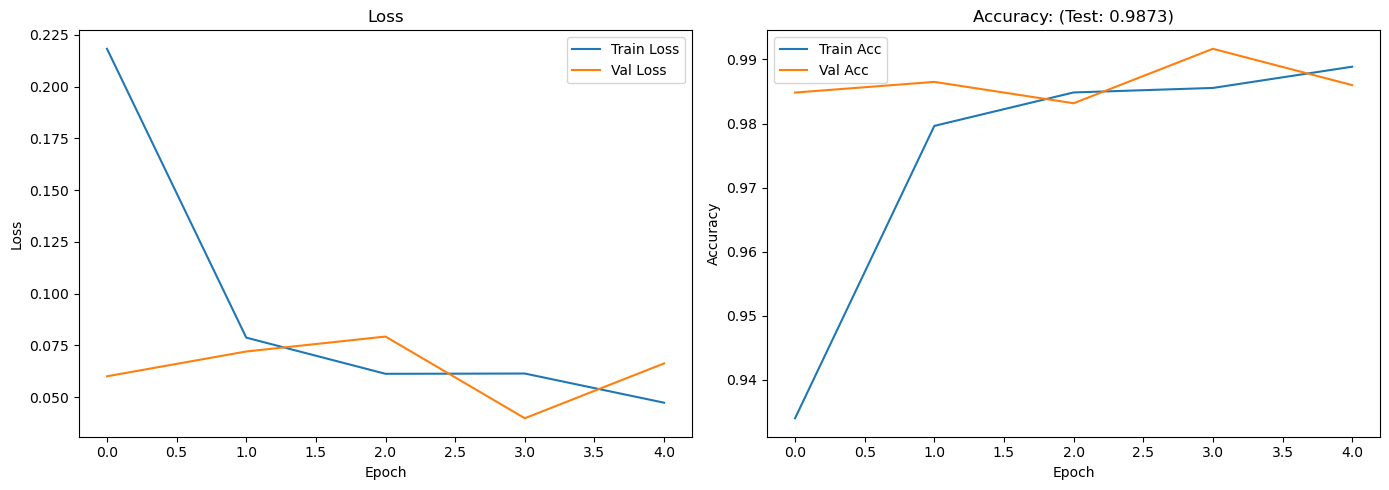

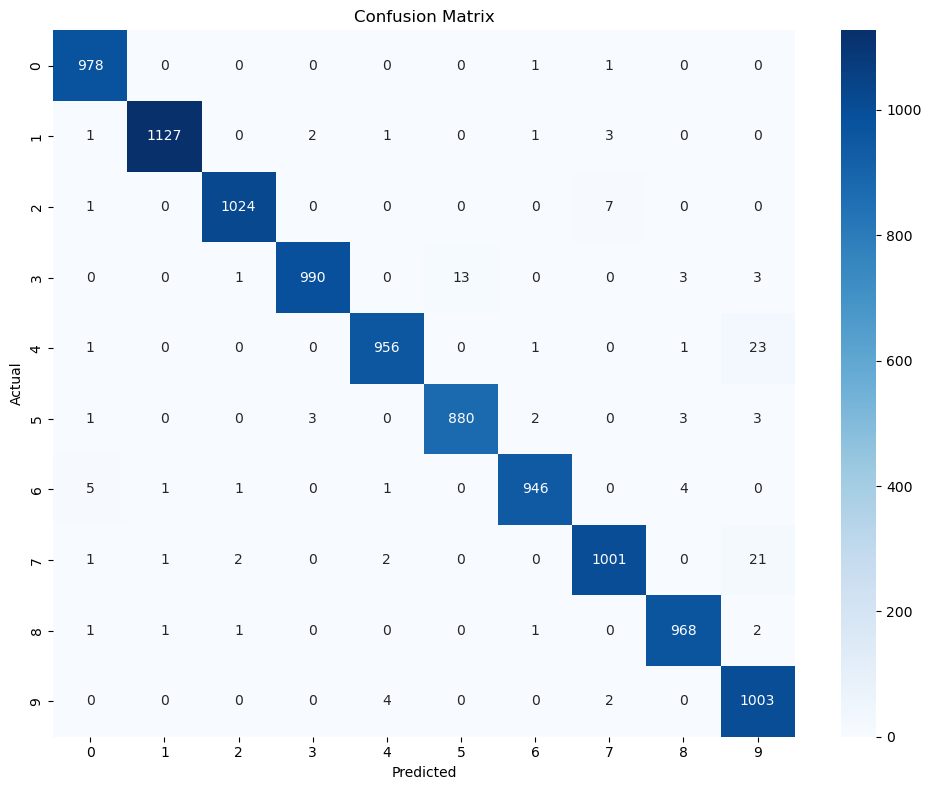

In [38]:
analytics = train_and_evaluate(alex_net_model_mnist, X_train_mnist, y_train_mnist,
                   X_test_mnist, y_test_mnist, epochs=5, batch_size=64, val_split=0.1)

plot_results(analytics, X_test_mnist, y_test_mnist)

* Cifar testing from here ->


* Default run (Of model also used for MNIST)

original_model = models.Sequential([
    
        layers.Conv2D(32, kernel_size=(3, 3), input_shape= input_size),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        layers.Conv2D(64, kernel_size=(3, 3)),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.4621 - loss: 1.4938 - val_accuracy: 0.5358 - val_loss: 1.3261
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6029 - loss: 1.1355 - val_accuracy: 0.6124 - val_loss: 1.0922
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6521 - loss: 1.0000 - val_accuracy: 0.6654 - val_loss: 0.9615
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.6878 - loss: 0.9004 - val_accuracy: 0.6844 - val_loss: 0.9160
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.7162 - loss: 0.8193 - val_accuracy: 0.6904 - val_loss: 0.9015
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.7388 - loss: 0.7507 - val_accuracy: 0.7086 - val_loss: 0.8615
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.7602 - loss: 0.6901 - val_accuracy: 0.7136 - val_loss: 0.8523
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.7801 - loss: 0.6348 - 

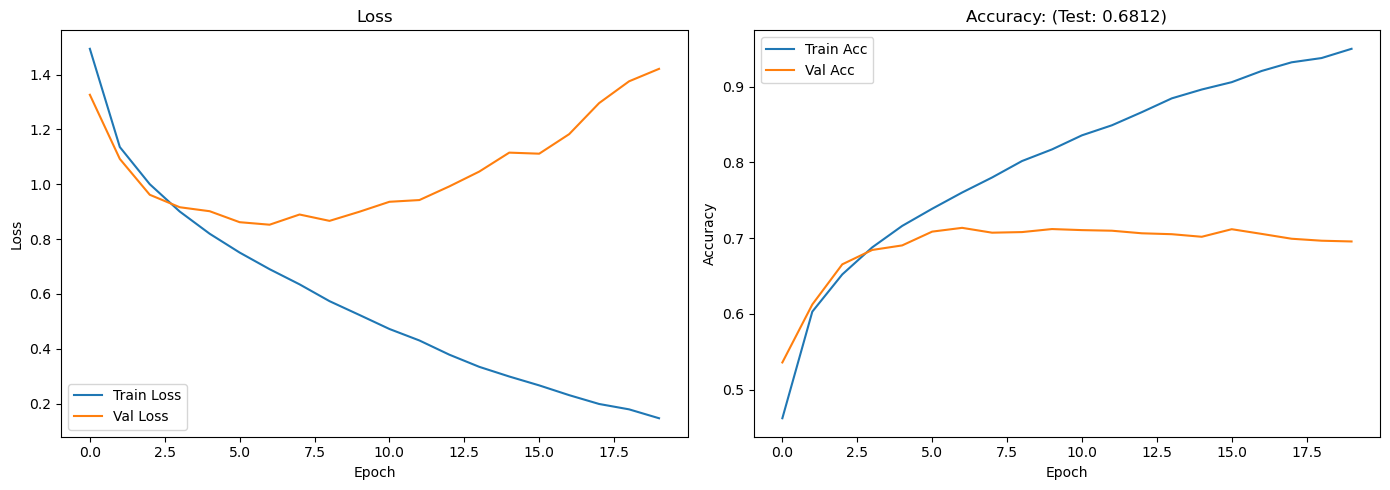

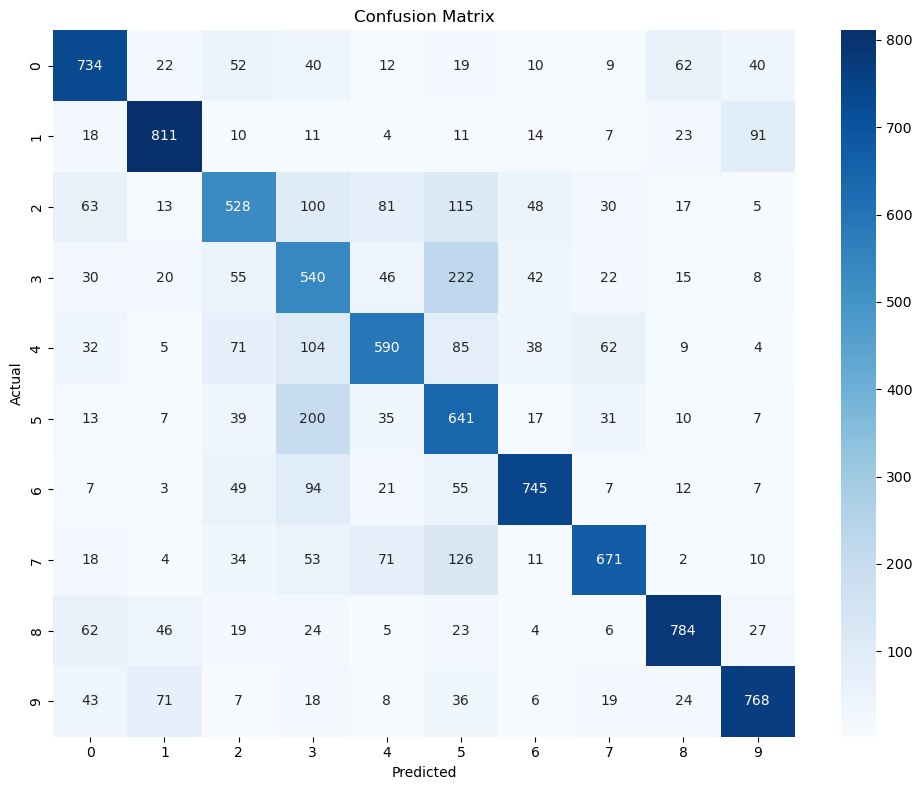

In [42]:
analytics = train_and_evaluate(original_model_cifar, X_train_cifar, y_train_cifar,
                   X_test_cifar, y_test_cifar, epochs=20)

plot_results(analytics, X_test_cifar, y_test_cifar)

* We can see that training acc is high compared to the val acc so we will add dropout

original_model = models.Sequential([

        layers.Conv2D(32, kernel_size=(3, 3), input_shape= input_size),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        layers.Conv2D(64, kernel_size=(3, 3)),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        layers.Flatten(),
        
        layers.Dense(128),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        
        layers.Dense(10, activation='softmax')
    ])

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.3962 - loss: 1.6531 - val_accuracy: 0.5428 - val_loss: 1.2954
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.5245 - loss: 1.3310 - val_accuracy: 0.6030 - val_loss: 1.1263
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.5722 - loss: 1.2061 - val_accuracy: 0.6124 - val_loss: 1.0876
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.6057 - loss: 1.1202 - val_accuracy: 0.6528 - val_loss: 1.0013
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.6282 - loss: 1.0547 - val_accuracy: 0.6734 - val_loss: 0.9348
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6517 - loss: 0.9941 - val_accuracy: 0.6770 - val_loss: 0.9305
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6660 - loss: 0.9493 - val_accuracy: 0.6908 - val_loss: 0.8888
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6821 - loss: 0.9048 - 

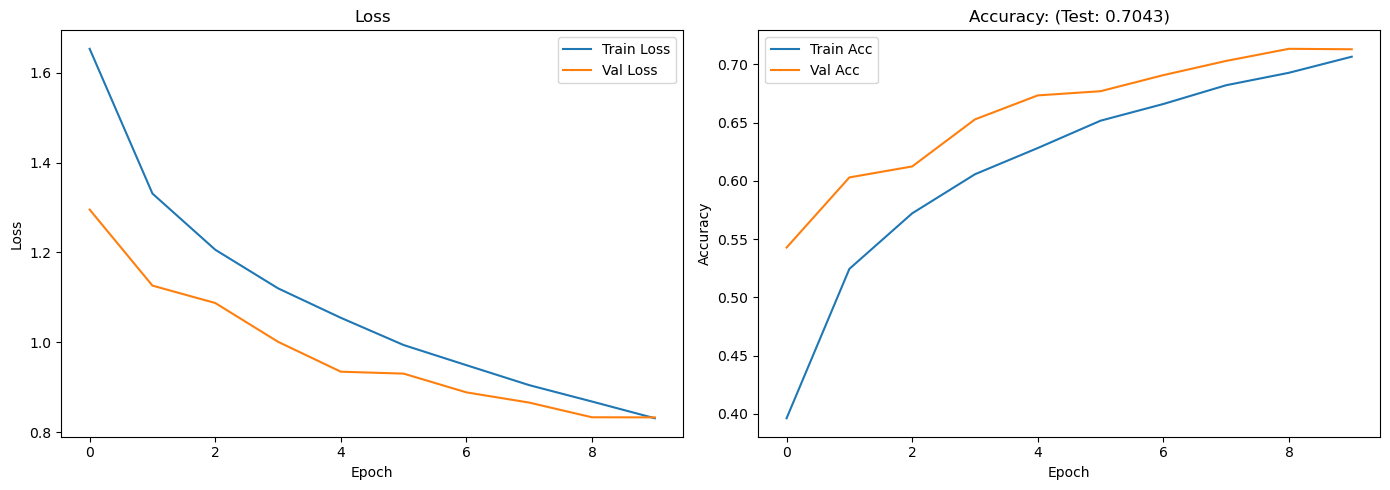

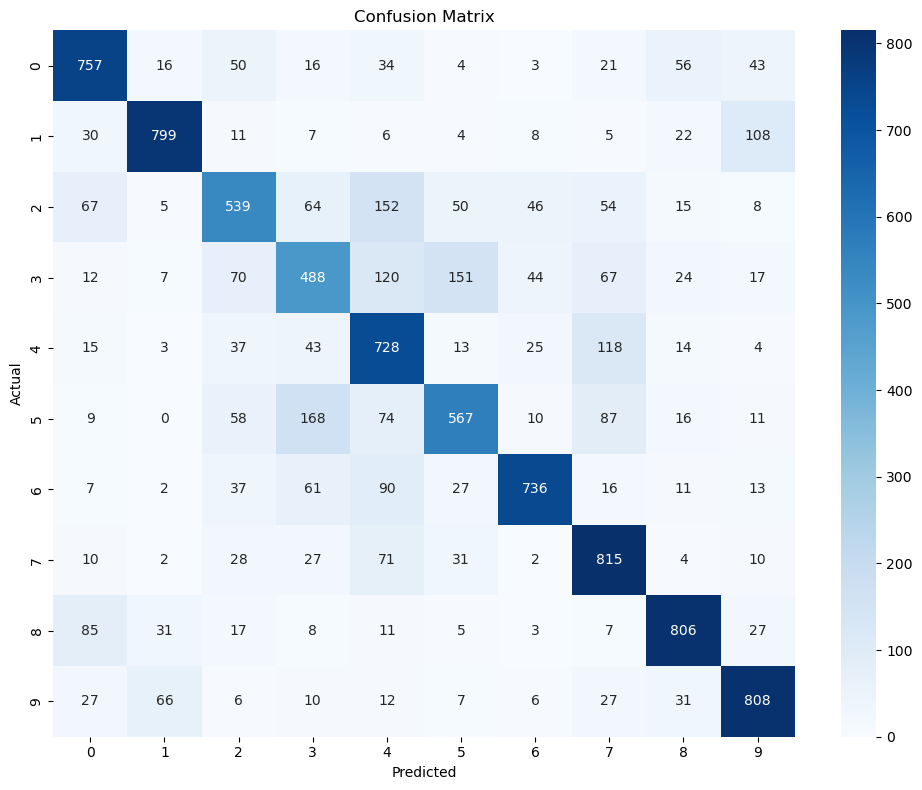

In [51]:
analytics = train_and_evaluate(original_model_cifar, X_train_cifar, y_train_cifar,
                   X_test_cifar, y_test_cifar, epochs=10)

plot_results(analytics, X_test_cifar, y_test_cifar)

* Changes
- new conv layer
- with new conv layer we also add the padding to not loose all info as image gets smaller
-  we also add batch norm to help converge better 
- we reduce dropout percentage
- we also remove one max-pooling 

    original_model = models.Sequential([
        
        layers.Conv2D(32, kernel_size=(3, 3), input_shape= input_size, padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        layers.Conv2D(64, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        
        layers.Conv2D(128, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        layers.Flatten(),
        
        layers.Dense(256),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        
        layers.Dense(10, activation='softmax')
    ])

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 112ms/step - accuracy: 0.3114 - loss: 1.8983 - val_accuracy: 0.3806 - val_loss: 1.6500
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.4305 - loss: 1.4947 - val_accuracy: 0.4234 - val_loss: 1.6145
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.4786 - loss: 1.3673 - val_accuracy: 0.5982 - val_loss: 1.1014
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.5112 - loss: 1.2899 - val_accuracy: 0.6172 - val_loss: 1.1147
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 117ms/step - accuracy: 0.5375 - loss: 1.2245 - val_accuracy: 0.6094 - val_loss: 1.0817
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.5569 - loss: 1.1833 - val_accuracy: 0.5752 - val_loss: 1.2307
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 120ms/step - accuracy: 0.5771 - loss: 1.1307 - val_accuracy: 0.6804 - val_loss: 0.9153
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.5944 - loss: 1

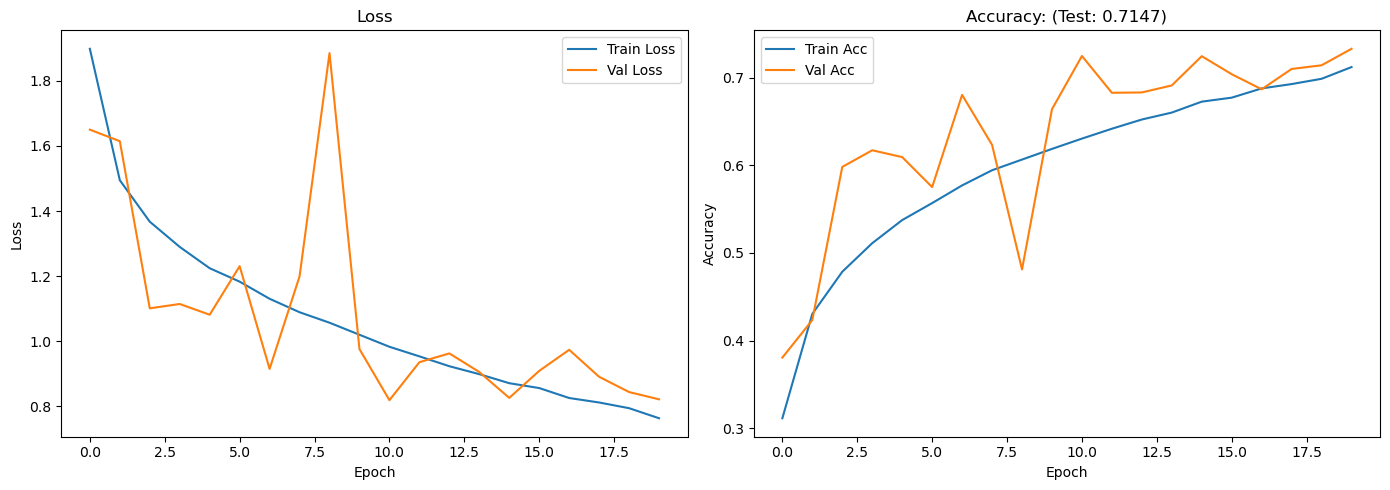

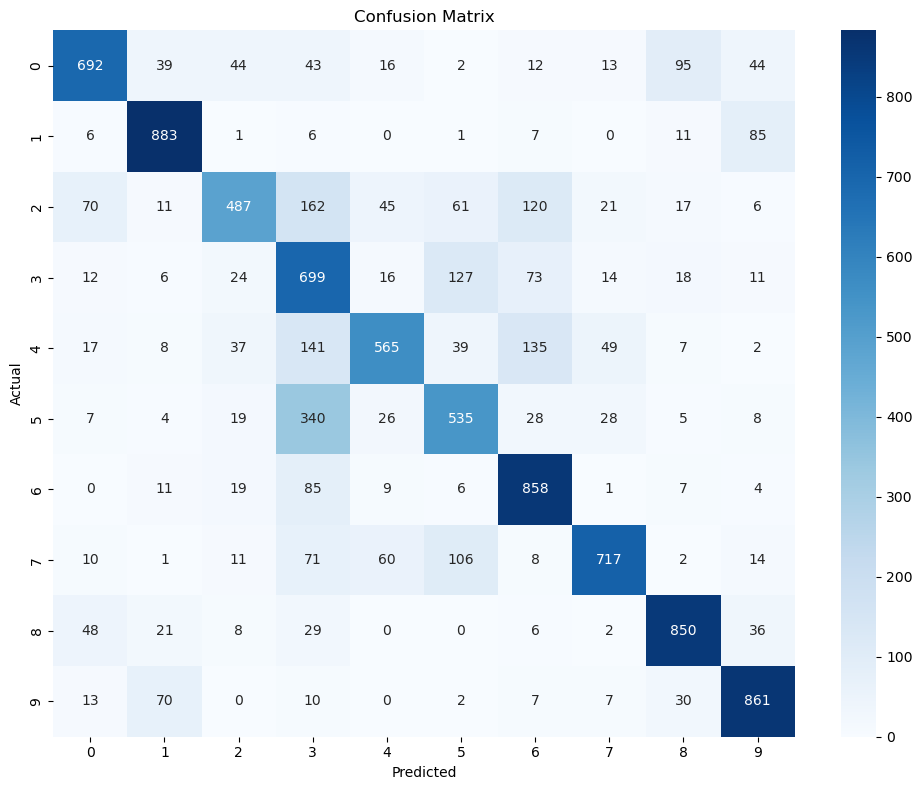

In [61]:
analytics = train_and_evaluate(original_model_cifar, X_train_cifar, y_train_cifar,
                   X_test_cifar, y_test_cifar, epochs=20)

plot_results(analytics, X_test_cifar, y_test_cifar)

* We try one more attempt with smaller learning rate

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 148ms/step - accuracy: 0.3846 - loss: 1.6989 - val_accuracy: 0.5570 - val_loss: 1.2562
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 139ms/step - accuracy: 0.5302 - loss: 1.2963 - val_accuracy: 0.4856 - val_loss: 1.5161
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 97s 138ms/step - accuracy: 0.5828 - loss: 1.1522 - val_accuracy: 0.6418 - val_loss: 0.9955
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 97s 138ms/step - accuracy: 0.6165 - loss: 1.0648 - val_accuracy: 0.5326 - val_loss: 1.3497
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 133ms/step - accuracy: 0.6463 - loss: 0.9855 - val_accuracy: 0.7038 - val_loss: 0.8683
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.6681 - loss: 0.9274 - val_accuracy: 0.7154 - val_loss: 0.8079
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.6840 - loss: 0.8767 - val_accuracy: 0.6972 - val_loss: 0.8501
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.6994 - loss: 

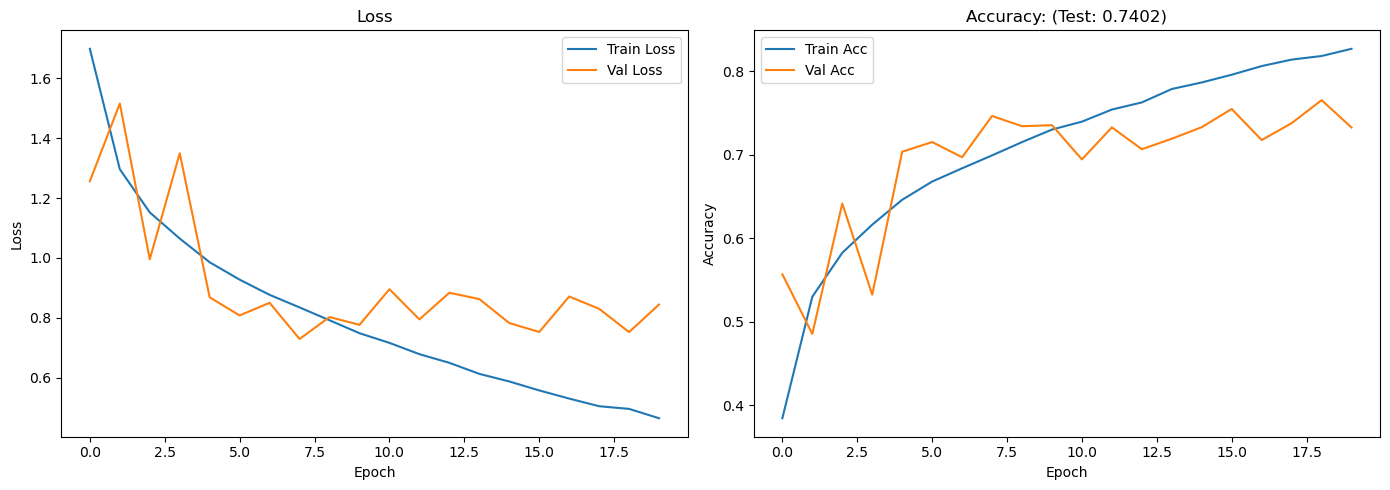

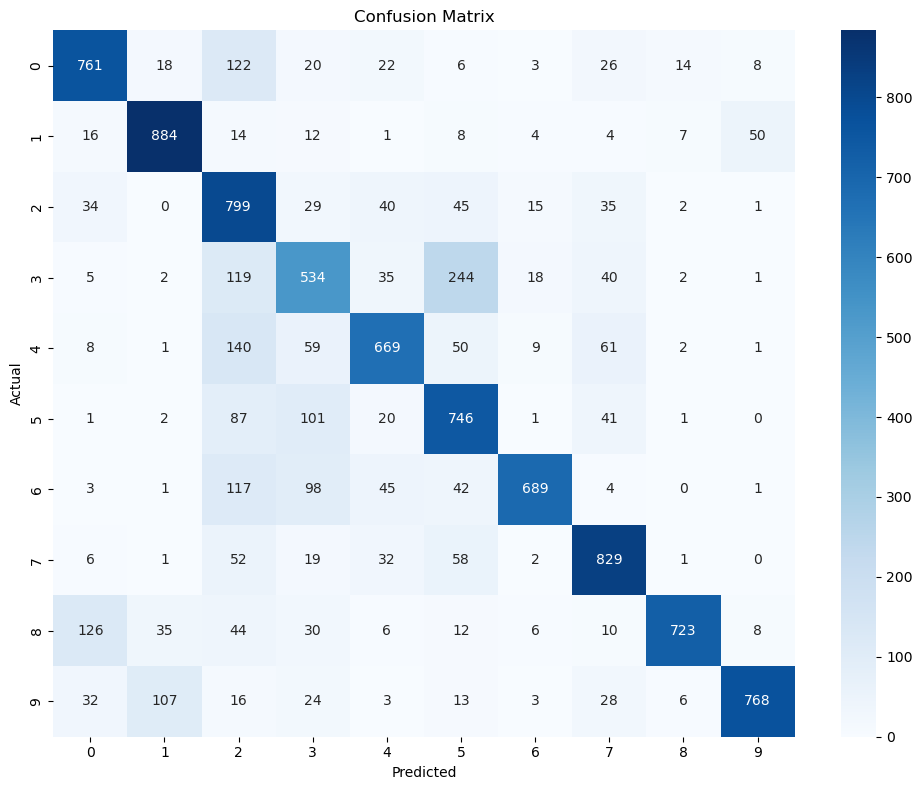

In [65]:
analytics = train_and_evaluate(original_model_cifar, X_train_cifar, y_train_cifar,
                   X_test_cifar, y_test_cifar, epochs=20)

plot_results(analytics, X_test_cifar, y_test_cifar)